
===== TRADE SUMMARY =====
 trade_id entry_date  exit_date     exdate  entry_dte  exit_dte  call_optionid  put_optionid  call_strike  put_strike  entry_call_delta  entry_put_delta  entry_call_mid  entry_put_mid  exit_call_mid  exit_put_mid     trade_pnl
        1 2022-08-29 2022-09-23 2022-09-30         32         7      148915193     148915214         15.0        15.0          0.497931        -0.505672           1.225          1.550          1.350         0.175 -1.500000e+02
        2 2022-09-26 2022-10-21 2022-10-28         32         7      149502992     149503013         17.0        17.0          0.505903        -0.483757           1.575          2.125          0.275         0.825 -3.552714e-15
        3 2022-10-24 2022-11-18 2022-11-25         32         7      150107801     150107822         16.5        16.5          0.495886        -0.510875           1.025          1.250          0.050         3.325  3.050000e+02
        4 2022-11-21 2022-12-16 2022-12-23         32         7  

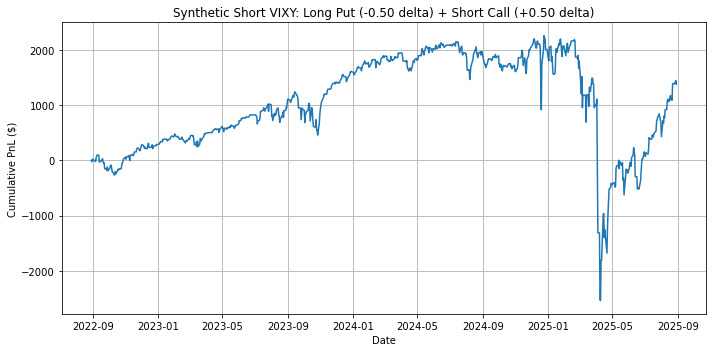

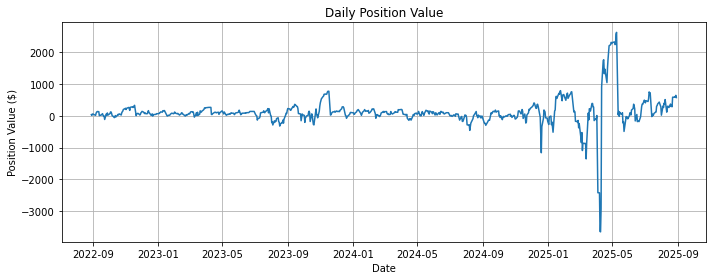

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# VIXY synthetic short using raw option data
# Entry:
#   - buy 1 put with delta closest to -0.50
#   - sell 1 call with delta closest to +0.50
#   - same expiration, target ~30 DTE
#
# Exit / Roll:
#   - hold exact option IDs
#   - roll when remaining DTE <= 7
#
# Assumptions:
#   - use mid price = (best_bid + best_offer)/2
#   - use only standard 100-share contracts
#   - carry forward missing quotes while position is open
#   - ignores commissions / slippage unless you add them
# ============================================================

FILE = "b10xheebr3v3h1vn.csv"

TARGET_DTE = 30
ROLL_DTE = 7
PUT_TARGET_DELTA = -0.50
CALL_TARGET_DELTA = 0.50
CONTRACTS = 1
MULTIPLIER = 100
COMMISSION_PER_CONTRACT_PER_LEG = 0.00   # e.g. 0.65 if you want
START_DATE = None                        # e.g. "2024-11-15"
END_DATE = None                          # optional


# Load and clean
df = pd.read_csv(FILE, low_memory=False)

df["date"] = pd.to_datetime(df["date"])
df["exdate"] = pd.to_datetime(df["exdate"])

if START_DATE is not None:
    df = df[df["date"] >= pd.to_datetime(START_DATE)].copy()
if END_DATE is not None:
    df = df[df["date"] <= pd.to_datetime(END_DATE)].copy()

# Use standard contracts only
df = df[df["contract_size"] == 100].copy()

# Keep rows with usable quotes and delta
df = df[
    df["best_bid"].notna() &
    df["best_offer"].notna() &
    df["delta"].notna()
].copy()

# Mid price and DTE
df["mid"] = (df["best_bid"] + df["best_offer"]) / 2.0
df["dte"] = (df["exdate"] - df["date"]).dt.days

# Keep only positive DTE
df = df[df["dte"] > 0].copy()

# Optional: filter out obviously bad quotes
df = df[df["best_offer"] >= df["best_bid"]].copy()

# Sort for stability
df = df.sort_values(["date", "exdate", "cp_flag", "strike_price"]).reset_index(drop=True)


# Helper: choose entry contracts on a given date
def select_entry_pair(day_df, target_dte=30, put_target=-0.50, call_target=0.50):
    """
    For a single trade date:
      1) find expiration closest to target_dte that has BOTH calls and puts
      2) within that expiration:
         - choose call with delta closest to +0.50
         - choose put  with delta closest to -0.50
    """
    if day_df.empty:
        return None

    # expirations available that have both C and P
    exp_counts = day_df.groupby(["exdate", "cp_flag"]).size().unstack(fill_value=0)
    valid_exdates = exp_counts[(exp_counts.get("C", 0) > 0) & (exp_counts.get("P", 0) > 0)].index

    if len(valid_exdates) == 0:
        return None

    exp_table = (
        day_df[day_df["exdate"].isin(valid_exdates)]
        .groupby("exdate", as_index=False)["dte"]
        .first()
    )
    exp_table["dte_dist"] = (exp_table["dte"] - target_dte).abs()
    chosen_exdate = exp_table.sort_values(["dte_dist", "dte"]).iloc[0]["exdate"]

    sub = day_df[day_df["exdate"] == chosen_exdate].copy()

    calls = sub[sub["cp_flag"] == "C"].copy()
    puts  = sub[sub["cp_flag"] == "P"].copy()

    if calls.empty or puts.empty:
        return None

    calls["delta_dist"] = (calls["delta"] - call_target).abs()
    puts["delta_dist"]  = (puts["delta"] - put_target).abs()

    chosen_call = calls.sort_values(["delta_dist", "dte", "strike_price"]).iloc[0]
    chosen_put  = puts.sort_values(["delta_dist", "dte", "strike_price"]).iloc[0]

    return {
        "date": chosen_call["date"],
        "exdate": chosen_call["exdate"],
        "dte": int(chosen_call["dte"]),
        "call_optionid": int(chosen_call["optionid"]),
        "put_optionid": int(chosen_put["optionid"]),
        "call_strike": chosen_call["strike_price"] / 1000.0,
        "put_strike": chosen_put["strike_price"] / 1000.0,
        "call_delta": float(chosen_call["delta"]),
        "put_delta": float(chosen_put["delta"]),
        "call_mid": float(chosen_call["mid"]),
        "put_mid": float(chosen_put["mid"]),
    }


# Build daily quote maps for exact option IDs
quote_map = (
    df[["date", "optionid", "mid", "exdate"]]
    .drop_duplicates(["date", "optionid"])
    .sort_values(["optionid", "date"])
    .reset_index(drop=True)
)

# Faster lookup by optionid
quotes_by_option = {
    oid: grp[["date", "mid"]].set_index("date").sort_index()
    for oid, grp in quote_map.groupby("optionid")
}

# Trading calendar
calendar = pd.DataFrame({"date": sorted(df["date"].unique())})


# Backtest
trades = []
daily_rows = []

in_position = False
current_trade = None
last_position_value = None

all_dates = calendar["date"].tolist()

for current_date in all_dates:
    day_df = df[df["date"] == current_date].copy()


    # If not in a trade, open one
    if not in_position:
        entry = select_entry_pair(
            day_df,
            target_dte=TARGET_DTE,
            put_target=PUT_TARGET_DELTA,
            call_target=CALL_TARGET_DELTA
        )

        if entry is not None:
            in_position = True
            current_trade = {
                "entry_date": current_date,
                "entry_exdate": entry["exdate"],
                "entry_dte": entry["dte"],
                "call_optionid": entry["call_optionid"],
                "put_optionid": entry["put_optionid"],
                "call_strike": entry["call_strike"],
                "put_strike": entry["put_strike"],
                "entry_call_delta": entry["call_delta"],
                "entry_put_delta": entry["put_delta"],
                "entry_call_mid": entry["call_mid"],
                "entry_put_mid": entry["put_mid"],
            }

            # initial position value: long put - short call
            last_position_value = (entry["put_mid"] - entry["call_mid"]) * MULTIPLIER * CONTRACTS

            entry_cost = 2 * COMMISSION_PER_CONTRACT_PER_LEG * CONTRACTS
            daily_rows.append({
                "date": current_date,
                "position_value": last_position_value,
                "daily_pnl": -entry_cost,
                "cum_trade_pnl": -entry_cost,
                "trade_open": True,
                "trade_id": len(trades) + 1,
                "call_optionid": current_trade["call_optionid"],
                "put_optionid": current_trade["put_optionid"],
                "dte": (current_trade["entry_exdate"] - current_date).days
            })
        continue


    # If in a trade, mark the exact option IDs
    call_oid = current_trade["call_optionid"]
    put_oid  = current_trade["put_optionid"]
    exdate   = current_trade["entry_exdate"]

    # Remaining DTE
    remaining_dte = (exdate - current_date).days

    # Get current quotes; if missing, carry forward last available quote
    call_px = np.nan
    put_px = np.nan

    if call_oid in quotes_by_option and current_date in quotes_by_option[call_oid].index:
        call_px = float(quotes_by_option[call_oid].loc[current_date, "mid"])
    if put_oid in quotes_by_option and current_date in quotes_by_option[put_oid].index:
        put_px = float(quotes_by_option[put_oid].loc[current_date, "mid"])

    # Carry forward from previous day if needed
    prev_row = daily_rows[-1] if len(daily_rows) > 0 else None
    if np.isnan(call_px) and prev_row is not None:
        call_px = prev_row.get("call_px", np.nan)
    if np.isnan(put_px) and prev_row is not None:
        put_px = prev_row.get("put_px", np.nan)

    # If still missing, skip MTM for the day
    if np.isnan(call_px) or np.isnan(put_px):
        daily_rows.append({
            "date": current_date,
            "position_value": last_position_value,
            "daily_pnl": 0.0,
            "cum_trade_pnl": (
                daily_rows[-1]["cum_trade_pnl"] if len(daily_rows) > 0 else 0.0
            ),
            "trade_open": True,
            "trade_id": len(trades) + 1,
            "call_optionid": call_oid,
            "put_optionid": put_oid,
            "call_px": call_px,
            "put_px": put_px,
            "dte": remaining_dte
        })
        continue

    position_value = (put_px - call_px) * MULTIPLIER * CONTRACTS
    daily_pnl = position_value - last_position_value
    last_position_value = position_value

    prev_cum_trade_pnl = daily_rows[-1]["cum_trade_pnl"] if len(daily_rows) > 0 else 0.0
    cum_trade_pnl = prev_cum_trade_pnl + daily_pnl

    daily_rows.append({
        "date": current_date,
        "position_value": position_value,
        "daily_pnl": daily_pnl,
        "cum_trade_pnl": cum_trade_pnl,
        "trade_open": True,
        "trade_id": len(trades) + 1,
        "call_optionid": call_oid,
        "put_optionid": put_oid,
        "call_px": call_px,
        "put_px": put_px,
        "dte": remaining_dte
    })


    # Roll condition: remaining DTE <= ROLL_DTE
    if remaining_dte <= ROLL_DTE:
        exit_cost = 2 * COMMISSION_PER_CONTRACT_PER_LEG * CONTRACTS
        daily_rows[-1]["daily_pnl"] -= exit_cost
        daily_rows[-1]["cum_trade_pnl"] -= exit_cost

        trades.append({
            "trade_id": len(trades) + 1,
            "entry_date": current_trade["entry_date"],
            "exit_date": current_date,
            "exdate": exdate,
            "entry_dte": current_trade["entry_dte"],
            "exit_dte": remaining_dte,
            "call_optionid": call_oid,
            "put_optionid": put_oid,
            "call_strike": current_trade["call_strike"],
            "put_strike": current_trade["put_strike"],
            "entry_call_delta": current_trade["entry_call_delta"],
            "entry_put_delta": current_trade["entry_put_delta"],
            "entry_call_mid": current_trade["entry_call_mid"],
            "entry_put_mid": current_trade["entry_put_mid"],
            "exit_call_mid": call_px,
            "exit_put_mid": put_px,
            "trade_pnl": daily_rows[-1]["cum_trade_pnl"]
        })

        in_position = False
        current_trade = None
        last_position_value = None


# Results
daily = pd.DataFrame(daily_rows)
trades_df = pd.DataFrame(trades)

if not daily.empty:
    daily = daily.sort_values("date").reset_index(drop=True)
    daily["cum_pnl"] = daily["daily_pnl"].cumsum()
    daily["daily_return_on_notional"] = daily["daily_pnl"] / (MULTIPLIER * CONTRACTS * 10_000)  # optional scaling

if not trades_df.empty:
    print("\n===== TRADE SUMMARY =====")
    print(trades_df.to_string(index=False))

if not daily.empty:
    print("\n===== PERFORMANCE SUMMARY =====")
    print(f"Total PnL ($): {daily['cum_pnl'].iloc[-1]:.2f}")
    print(f"Number of completed trades: {len(trades_df)}")
    print(f"Average trade PnL ($): {trades_df['trade_pnl'].mean():.2f}" if not trades_df.empty else "Average trade PnL ($): N/A")
    print(f"Win rate: {(trades_df['trade_pnl'] > 0).mean():.2%}" if not trades_df.empty else "Win rate: N/A")

    plt.figure(figsize=(10, 5))
    plt.plot(daily["date"].to_numpy(), daily["cum_pnl"].to_numpy())
    plt.title("Synthetic Short VIXY: Long Put (-0.50 delta) + Short Call (+0.50 delta)")
    plt.xlabel("Date")
    plt.ylabel("Cumulative PnL ($)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(daily["date"].to_numpy(), daily["position_value"].to_numpy())
    plt.title("Daily Position Value")
    plt.xlabel("Date")
    plt.ylabel("Position Value ($)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

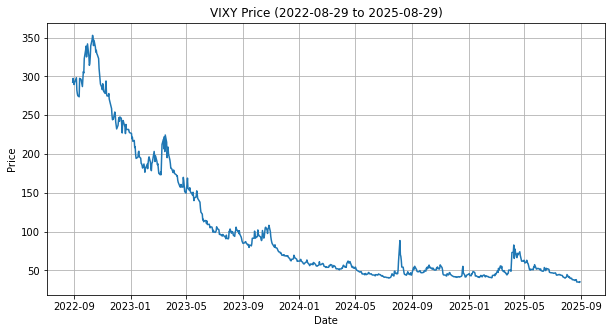

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your Yahoo file
vixy = pd.read_csv("HistoricalData_1774985169796.csv")

# Convert date
vixy["Date"] = pd.to_datetime(vixy["Date"])

# Filter the exact range
start = pd.to_datetime("2022-08-29")
end   = pd.to_datetime("2025-08-29")

vixy_filtered = vixy[
    (vixy["Date"] >= start) &
    (vixy["Date"] <= end)
].copy()

# Sort (important for plotting)
vixy_filtered = vixy_filtered.sort_values("Date")

# Plot
plt.figure(figsize=(10,5))
plt.plot(
    vixy_filtered["Date"].to_numpy(),
    vixy_filtered["Close/Last"].to_numpy()
)
plt.title("VIXY Price (2022-08-29 to 2025-08-29)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()

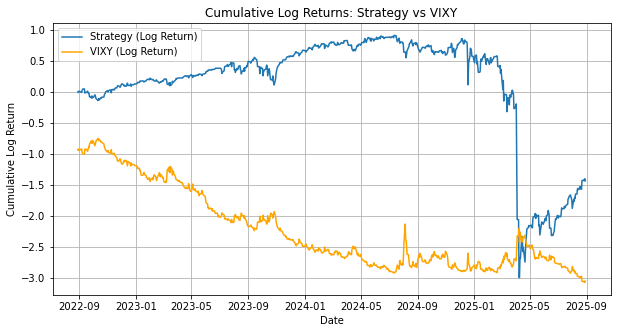

In [16]:
import numpy as np

vixy = vixy.sort_values("Date").copy()

# log return
vixy["vixy_log_ret"] = np.log(vixy["Close/Last"] / vixy["Close/Last"].shift(1))

# cumulative log return
vixy["vixy_cum_log"] = vixy["vixy_log_ret"].cumsum()

# approximate notional (important!)
NOTIONAL = 2000  # adjust if needed

daily = daily.sort_values("date").copy()

# convert PnL to return
daily["strategy_ret"] = daily["daily_pnl"] / NOTIONAL

# log return
daily["strategy_log_ret"] = np.log(1 + daily["strategy_ret"])

# cumulative log return
daily["strategy_cum_log"] = daily["strategy_log_ret"].cumsum()

merged = pd.merge(
    daily[["date", "strategy_cum_log"]],
    vixy[["Date", "vixy_cum_log"]],
    left_on="date",
    right_on="Date",
    how="inner"
)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    merged["date"].to_numpy(),
    merged["strategy_cum_log"].to_numpy(),
    label="Strategy (Log Return)"
)

plt.plot(
    merged["date"].to_numpy(),
    merged["vixy_cum_log"].to_numpy(),
    label="VIXY (Log Return)",
    color="orange"
)

plt.title("Cumulative Log Returns: Strategy vs VIXY")
plt.xlabel("Date")
plt.ylabel("Cumulative Log Return")
plt.legend()
plt.grid(True)
plt.show()